Tamanho do conjunto de treino: 7591 amostras
Tamanho do conjunto de teste: 6228 amostras

gen	nevals	min    	mean     	max      
0  	20    	0.04232	0.0433658	0.0443598
1  	16    	0.0430006	0.0435424	0.0443598
2  	17    	0.0418997	0.0435466	0.0449393
3  	19    	0.0429606	0.0436194	0.0449393
4  	17    	0.0430424	0.0439575	0.0453143
5  	16    	0.0433838	0.0443951	0.0456443
6  	14    	0.0423549	0.04442  	0.0456439
7  	19    	0.0434389	0.0446396	0.0456439
8  	15    	0.0418101	0.044889 	0.0456439
9  	16    	0.0437206	0.0454686	0.0456439
10 	16    	0.0456439	0.0456439	0.0456439
11 	18    	0.0427101	0.0451765	0.0459112
12 	17    	0.0415696	0.0453575	0.0459112
13 	18    	0.0423059	0.0454365	0.0459112
14 	17    	0.0431208	0.0454144	0.0459112
15 	15    	0.0434578	0.0456549	0.0459112
16 	18    	0.043509 	0.0457973	0.046036 
17 	11    	0.0431288	0.0456786	0.046036 
18 	18    	0.0431878	0.0454393	0.046036 
19 	19    	0.0421306	0.0450518	0.046036 
20 	16    	0.0427948	0.0455636	0.0463443
21 	20    	0

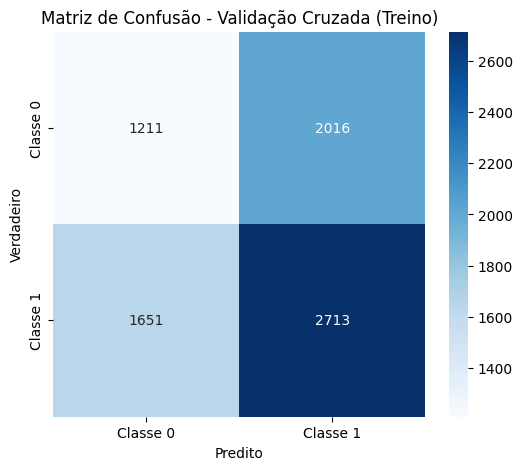


Gerando Matriz de Confusão do Período de Teste...


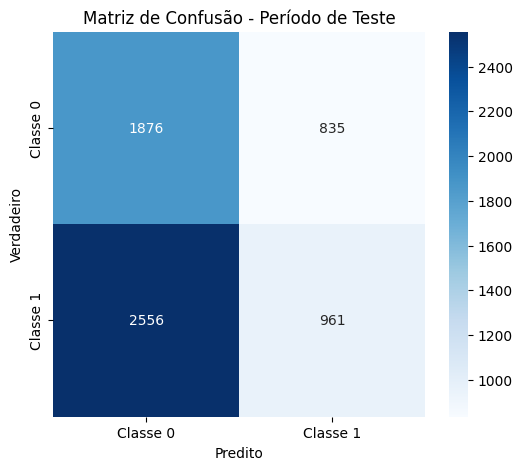

Melhor Fitness Encontrado: 0.0465
Melhores Hiperparâmetros:
  - hidden_layer_sizes: 159
  - activation: tanh
  - alpha: 0.046192668621700884
  - learning_rate_init: 0.09667976539589444
  - max_iter: 157

Previsões das matrizes de confusão combinadas com sucesso.

 O arquivo 'candles_previstos_como_1.csv' foi criado com sucesso.
Ele contém 6525 candles que o modelo previu como '1'.


In [ ]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix


try:
    df = pd.read_csv('data_with_errors_v2.csv')

    df['datetime'] = pd.to_datetime(df['datetime'])

    if 'id_ticker' in df.columns:
        df.drop_duplicates(subset=['datetime', 'id_ticker'], keep='first', inplace=True)
    else:
        df.drop_duplicates(subset=['datetime'], keep='first', inplace=True)

    df.sort_values(by='datetime', inplace=True)

except FileNotFoundError:
    print("Erro: O arquivo 'data_with_errors.csv' não foi encontrado.")
    dates = pd.to_datetime(pd.date_range(start='2024-01-01', end='2024-06-30', freq='h'))
    data = {
        'datetime': dates,
        'Bands_Norm': np.random.rand(len(dates)),
        'NSMA_3': np.random.rand(len(dates)),
        'NSMA_5': np.random.rand(len(dates)),
        'NSMA_7': np.random.rand(len(dates)),
        'NSMA_9': np.random.rand(len(dates)),
        'NSMA_11': np.random.rand(len(dates)),
        'ERRORS': np.random.randint(0, 2, len(dates))
    }
    df = pd.DataFrame(data)
    df.to_csv('data_with_errors.csv', index=False)
    print("Arquivo 'data_with_errors.csv' de exemplo criado.")


features = ['Bands_Norm', 'NSMA_3', 'NSMA_5', 'NSMA_7', 'NSMA_9','NSMA_11']
target = 'ERRORS'

train_start, train_end = '2024-01-01', '2024-03-30'
test_start, test_end = '2024-04-01', '2024-06-30'

train_df = df[(df['datetime'] >= train_start) & (df['datetime'] <= train_end)]
test_df = df[(df['datetime'] >= test_start) & (df['datetime'] <= test_end)]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras\n")


param_ranges = {
    'hidden_layer_sizes': (10, 200),
    'activation': (0, 2),
    'alpha': (0.0001, 0.1),
    'learning_rate_init': (0.0001, 0.1),
    'max_iter': (100, 500),
}

param_bits = {
    'hidden_layer_sizes': 8,
    'activation': 2,
    'alpha': 10,
    'learning_rate_init': 10,
    'max_iter': 9,
}

activation_map = {
    0: 'relu',
    1: 'tanh',
    2: 'logistic'
}

total_bits = sum(param_bits.values())

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()

toolbox.register("attr_bin", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bin, total_bits)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


def decode_binary(gene, minimo, maximo, n_bits):
    binary_str = ''.join(map(str, gene))
    int_value = int(binary_str, 2)
    max_value = 2 ** n_bits - 1
    return minimo + (int_value / max_value) * (maximo - minimo)


def decode_individual(individual):
    idx = 0
    decoded = {}
    for param, (min_val, max_val) in param_ranges.items():
        bits = param_bits[param]
        value = decode_binary(individual[idx:idx+bits], min_val, max_val, bits)
        if param in ['hidden_layer_sizes', 'max_iter']:
            value = int(round(value))
        elif param == 'activation':
            value = activation_map[int(round(value))]
        decoded[param] = value
        idx += bits
    return decoded


def calculate_fitness(individual):
    params = decode_individual(individual)
    
    if params['hidden_layer_sizes'] == 0:
        return (0.0,)
        
    model = MLPClassifier(
        hidden_layer_sizes=(params['hidden_layer_sizes'],),
        activation=params['activation'],
        alpha=params['alpha'],
        learning_rate_init=params['learning_rate_init'],
        max_iter=params['max_iter'],
        random_state=42
    )
    
    try:
        skf = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)
        cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
        train_acc = np.mean(cv_scores)

        model.fit(X_train, y_train)
        y_pred_test = model.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred_test)
        
        test_precision = precision_score(y_test, y_pred_test, zero_division=0)

        base_fitness = (0.4 * train_acc) + (0.6 * test_acc)
        penalty = (0.10) * (1 - test_precision)

        final_fitness =  penalty

    except Exception as e:
        final_fitness = 0.0 
        
    return (final_fitness,)


toolbox.register("evaluate", calculate_fitness)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)


def main(n_gen=1000, pop_size=20, cxpb=0.8, mutpb=0.2):
    population = toolbox.population(n=pop_size)
    hof = tools.HallOfFame(1)
    
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("mean", np.mean)
    stats.register("max", np.max)
    
    population, logbook = algorithms.eaSimple(
        population,
        toolbox,
        cxpb=cxpb,
        mutpb=mutpb,
        ngen=n_gen,
        stats=stats,
        halloffame=hof,
        verbose=True
    )

    best_individual = hof[0]
    best_params = decode_individual(best_individual)
    best_fitness = best_individual.fitness.values[0]

    evolution_df = pd.DataFrame(logbook.chapters['fitness'])
    evolution_df['gen'] = logbook.select('gen')
    evolution_df.set_index('gen', inplace=True)
    print(evolution_df)
    
    def plot_confusion_matrix(cm, title, class_names=['Classe 0', 'Classe 1']):
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(title)
        plt.ylabel('Verdadeiro')
        plt.xlabel('Predito')
        plt.show()

    best_model = MLPClassifier(
        hidden_layer_sizes=(best_params['hidden_layer_sizes'],),
        activation=best_params['activation'],
        alpha=best_params['alpha'],
        learning_rate_init=best_params['learning_rate_init'],
        max_iter=best_params['max_iter'],
        random_state=42
    )

    print("\nGerando Matriz de Confusão da Validação Cruzada (9-Folds)...")
    skf_final = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)
    y_pred_cv = cross_val_predict(best_model, X_train, y_train, cv=skf_final)
    cm_cv = confusion_matrix(y_train, y_pred_cv)
    plot_confusion_matrix(cm_cv, 'Matriz de Confusão - Validação Cruzada (Treino)')

    print("\nGerando Matriz de Confusão do Período de Teste...")
    best_model.fit(X_train, y_train)
    y_pred_final_test = best_model.predict(X_test)
    cm_test = confusion_matrix(y_test, y_pred_final_test)
    plot_confusion_matrix(cm_test, 'Matriz de Confusão - Período de Teste')

    print(f'Melhor Fitness Encontrado: {best_fitness:.4f}')
    print('Melhores Hiperparâmetros:')
    for k, v in best_params.items():
        print(f"  - {k}: {v}")

    return best_individual, best_params, best_fitness, y_pred_cv, y_pred_final_test


if __name__ == '__main__':
    best_individual, best_params, best_fitness, previsoes_treino, previsoes_teste = main(n_gen=1000, pop_size=20)

    try:
        df_completo = df.copy()
    except NameError:
        print("\nDataFrame 'df' não encontrado, carregando 'data_training.csv' novamente...")
        try:
            df_completo = pd.read_csv('data_training.csv')
            df_completo['datetime'] = pd.to_datetime(df_completo['datetime'])
            if 'id_ticker' in df_completo.columns:
                df_completo.drop_duplicates(subset=['datetime', 'id_ticker'], keep='first', inplace=True)
            else:
                df_completo.drop_duplicates(subset=['datetime'], keep='first', inplace=True)
        except FileNotFoundError:
            df_completo = pd.DataFrame()

    if not df_completo.empty:
        df_completo['previsao'] = np.nan
        df_completo.loc[X_train.index, 'previsao'] = previsoes_treino
        df_completo.loc[X_test.index, 'previsao'] = previsoes_teste
        
        print("\nPrevisões das matrizes de confusão combinadas com sucesso.")

        candles_preditos_como_1 = df_completo[df_completo['previsao'] == 1].copy()
        
        colunas_desejadas = ['datetime', 'Bands_Norm', 'NSMA_3', 'NSMA_5', 'NSMA_7', 'NSMA_9', 'NSMA_11', 'trend']
        colunas_existentes = [col for col in colunas_desejadas if col in candles_preditos_como_1.columns]
        
        df_final = candles_preditos_como_1[colunas_existentes].copy()
        
        if 'datetime' in df_final.columns:
            df_final.rename(columns={'datetime': 'date'}, inplace=True)

        nome_arquivo_saida = 'candles_previstos_como_1.csv'

        if df_final.empty:
            print("\nAVISO: O modelo não previu '1' para nenhum dos candles.")
        else:
            df_final.to_csv(nome_arquivo_saida, index=False)
            print(f"\n O arquivo '{nome_arquivo_saida}' foi criado com sucesso.")
            print(f"Ele contém {len(df_final)} candles que o modelo previu como '1'.")